# Week 8 Evaluation Expansion
- Compute metrics beyond R²: MAPE and MdAPE. (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.median_absolute_error.html)
    - Why is it difficult to find things on MdAPE? (https://stats.stackexchange.com/questions/596324/is-median-absolute-percentage-error-useless)
- Summarize insights (which price bands performed better)

- I'll clean up the code from previous files and re-do it here for better readability (and convenience)
- Hyperparameter tuning (https://www.geeksforgeeks.org/machine-learning/sklearn-model-hyper-parameters-tuning/)

In [43]:
# Importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Hyperparameter tuning modules
from sklearn.model_selection import GridSearchCV

# Regression modules
from sklearn.linear_model import LinearRegression
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error

# Tree modules
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# XGBoost
from xgboost import XGBRegressor
from scipy.stats import loguniform
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

In [44]:
""" 
    Custom function to con
"""
def median_absolute_percentage_error(dataset, predicted_value):
    return np.median(abs(dataset - predicted_value) / abs(dataset)) * 100

""" 
    Function wrapper so I don't have to rewrite my existing functions
"""
def median_absolute_error(dataset, predicted_value):
    return median_absolute_percentage_error(dataset, predicted_value)
    

# Data Wrangling
Import and split data properly

In [45]:
# Importing cleaned data
root = "C:/Users/donutii/Desktop/IDX-Exchange-Internship-Data-Science-61"
data_location = f"{root}/IDX_Exchange/deliverables"

testing_set = pd.read_csv(f'{data_location}/CRMLS_202605_testing_set.csv')
training_set = pd.read_csv(f'{data_location}/CRMLS_202505_202604_training_set.csv') 

# feature engineered datasets
testing_set_fe = pd.read_csv(f'{data_location}/CRMLS_202605_testing_set_fe.csv')
training_set_fe = pd.read_csv(f'{data_location}/CRMLS_202505_202604_training_set_fe.csv') 

In [46]:
# Splitting training set into different months to test hyperparameter
months = ['2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2025-06']
training_set_split_by_months = []
for month in range(len(months)):
    training_set_split_by_months.append(training_set[training_set['CloseDate'].str.contains(months[month])])
    #(training_set_months[month].columns)
    training_set_split_by_months[month] = training_set_split_by_months[month].drop(columns='CloseDate')

# Get Target and Normal Vars from the Testing set
testing_vars = testing_set.drop(columns='ClosePrice')
testing_target = testing_set['ClosePrice']

In [47]:
# Do the same with featured engineered sets

training_set_months_fe = []
for month in range(len(months)):
    training_set_months_fe.append(training_set_fe[training_set_fe['CloseDate'].str.contains(months[month])])
    #(training_set_months[month].columns)
    training_set_months_fe[month] = training_set_months_fe[month].drop(columns='CloseDate')
    
testing_vars_fe = testing_set_fe.drop(columns='ClosePrice')
testing_target_fe = testing_set_fe['ClosePrice']

In [48]:
""" 
    Function to test different time frames of training data
    You can include up to 13 months
"""
def choose_test_months(num_months):
    if(num_months > 13 or num_months < 1):
        num_months = 13
        
    included_months = []
    for month in range(num_months):
        included_months.append(training_set_split_by_months[12 - month])
    
    return pd.concat(included_months, axis=0)

""" 
    Function to split trianing data into its variables and target
"""
def get_training_split(training_data):
    training_vars = training_data.drop(columns='ClosePrice')
    training_target = training_data['ClosePrice']
    
    return training_vars, training_target

In [49]:
# Creating dataframe used to store scores between models
evaluations = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE', 'Hyperparameters'])


# Baseline Model
- From 03_baseline_model.ipynb
- A simple regression model using sklearn
- Test out number of months as hyperparameter

In [50]:
def baseline_regression_model():
    # number of months
    num_months = [1, 6, 12, 13]
    
    regression_model_performance = pd.DataFrame(columns=['Num_Months', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
    
    for num in num_months:
        training_data = choose_test_months(num_months=num)
        training_vars, training_target = get_training_split(training_data)
        
        # Create models
        model = LinearRegression().fit(training_vars, training_target)
        
        new_row = pd.DataFrame([{
            'Num_Months': num,
            'Model': f'BaselineRegressor_{num}months',
            'Training_R2': model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, model.predict(training_vars)),
            'R2': model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, model.predict(testing_vars)),
            'Hyperparameters': None
        }])

        regression_model_performance = pd.concat(
            [regression_model_performance, new_row],
            ignore_index=True
        )
        
        print(f"R2 of model trained on {num} months: {model.score(testing_vars, testing_target)}")

    
    regression_model_performance = regression_model_performance.sort_values(by='R2', ascending=False)
    print("Baseline Model Performance Summary:")    
    print(regression_model_performance)
    
    return regression_model_performance.iloc[:1]
    
    
    

In [51]:
# Regress normal data
best_model = baseline_regression_model()

print("Baseline Regression Performance:")
print(best_model)

evaluations = pd.concat([evaluations, best_model], axis=0, ignore_index=True)


C:\Users\donutii\AppData\Local\Temp\ipykernel_26612\2206378741.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  regression_model_performance = pd.concat(


R2 of model trained on 1 months: 0.4474074546268124
R2 of model trained on 6 months: 0.7018661811650542
R2 of model trained on 12 months: 0.7215168470647313
R2 of model trained on 13 months: 0.7215586516096621
Baseline Model Performance Summary:
  Num_Months  Training_R2  Training_MdAPE  Training_MAPE        R2      MdAPE  \
3         13     0.707523       24.172029      13.891963  0.721559  23.063179   
2         12     0.706574       24.181805      13.893092  0.721517  23.020604   
1          6     0.720403       23.445483      14.667433  0.701866  22.166358   
0          1     0.726964       22.877836      13.865004  0.447407  48.964854   

        MAPE                       Model Hyperparameters  
3  12.060183  BaselineRegressor_13months            None  
2  12.031524  BaselineRegressor_12months            None  
1  12.381862   BaselineRegressor_6months            None  
0  22.311199   BaselineRegressor_1months            None  
Baseline Regression Performance:
  Num_Months  Traini

C:\Users\donutii\AppData\Local\Temp\ipykernel_26612\1413416658.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  evaluations = pd.concat([evaluations, best_model], axis=0, ignore_index=True)


In [52]:
# Regress feature engineered data

# Regression Decision Tree
- From 04_model_comparison.ipynb
- DecisionTree using sklearn
- DecisionTrees are also relatively cheap in processing so I will use grid search here as well

In [53]:
def decisiontree_regression_model(num_months):
    params = {
        "criterion" : ['squared_error', 'friedman_mse', 'poisson'],
        "max_depth" : [20, 30, 40, 60],
        "min_samples_split": [2, 4, 8],
        "min_samples_leaf": [1, 0.01, 0.05, 0.10],
        "max_features": [None, 'sqrt', 'log2']
    }
    
    training_data = choose_test_months(num_months)
    training_vars, training_target = get_training_split(training_data)
    
    # Create a GridSearch CV
    model_grid_searchcv = GridSearchCV(DecisionTreeRegressor(), params, cv=5, 
                                       scoring={'R2': 'r2', 'MdAPE': 'neg_median_absolute_error', 'MAPE': 'neg_mean_absolute_percentage_error'}, 
                                       refit='R2', n_jobs=-1)
    
    # Fit to training data
    model_grid_searchcv.fit(training_vars, training_target)
    
    # create cv
    cv_results = pd.DataFrame(model_grid_searchcv.cv_results_)
    cv_results["R2"] = -cv_results["mean_test_R2"]
    cv_results["MdAPE"] = -cv_results["mean_test_MdAPE"]
    cv_results["MAPE"] = cv_results["mean_test_MAPE"]
    
    print(f"Decision Tree Regression Model Performance for {num_months} months:")
    print(cv_results)
    
    # return the best model
    return model_grid_searchcv.best_estimator_

In [54]:
# regress normal data

model_aggregates = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
num_months = [1, 6, 12, 13]
for months in num_months:
    training_data = choose_test_months(num_months=months)
    training_vars, training_target = get_training_split(training_data)
    
    best_model = decisiontree_regression_model(months)
    
    new_row = pd.DataFrame([{
            'Num_Months': months,
            'Model': f'DecisionTreeRegressor_{months}months',
            'Training_R2': best_model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, best_model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, best_model.predict(training_vars)),
            'R2': best_model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, best_model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, best_model.predict(testing_vars)),
            'Hyperparameters': best_model.get_params
        }])
    model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)
    

print("Best model from different windows of training data:")    
model_aggregates = model_aggregates.sort_values(by='R2', ascending=False)
print(model_aggregates)    
evaluations = pd.concat([evaluations, model_aggregates.iloc[:1]], ignore_index=True)

Decision Tree Regression Model Performance for 1 months:
     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0         0.221241      0.012520         0.005825        0.000775   
1         0.198229      0.003166         0.004555        0.000833   
2         0.186271      0.005835         0.003819        0.000407   
3         0.084113      0.003480         0.005188        0.002420   
4         0.088386      0.009390         0.003591        0.000554   
..             ...           ...              ...             ...   
427       0.018272      0.002837         0.004351        0.000449   
428       0.016757      0.002765         0.003374        0.000416   
429       0.013127      0.002479         0.006329        0.005883   
430       0.013337      0.001748         0.003735        0.000709   
431       0.014192      0.002190         0.003955        0.000870   

    param_criterion  param_max_depth param_max_features  \
0     squared_error               20               None

C:\Users\donutii\AppData\Local\Temp\ipykernel_26612\1377743478.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)


Decision Tree Regression Model Performance for 6 months:
     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0         1.172962      0.047157         0.010767        0.001840   
1         1.163250      0.093065         0.010831        0.001501   
2         1.095915      0.122893         0.011729        0.007528   
3         0.447150      0.015671         0.006184        0.001366   
4         0.465438      0.054688         0.006798        0.001165   
..             ...           ...              ...             ...   
427       0.069920      0.005899         0.005513        0.000640   
428       0.064013      0.005134         0.006131        0.000967   
429       0.057884      0.010923         0.006748        0.000784   
430       0.051689      0.007701         0.006586        0.001254   
431       0.046252      0.007701         0.004512        0.000925   

    param_criterion  param_max_depth param_max_features  \
0     squared_error               20               None

# Random Forest Regressor
- Also from 04_model_comparison.ipynb
- Using randomsearch because processing these takes quite a while

In [55]:

def randomforest_regression_model(num_months):
    params = {
        "criterion" : ['squared_error', 'friedman_mse', 'poisson'],
        "max_depth" : [20, 30, 40, 60],
        "max_features": ['sqrt', 'log2', None],
        "random_state": [20, 42, 60]
        # TODO: get more params here
    }
    
    training_data = choose_test_months(num_months)
    training_vars, training_target = get_training_split(training_data)
    
    # Create a Random Search CV
    model_rand_searchcv = RandomizedSearchCV(RandomForestRegressor(), params, cv=5, 
                                            scoring={'R2': 'r2', 'MdAPE': 'neg_median_absolute_error', 'MAPE': 'neg_mean_absolute_percentage_error'}, 
                                            refit='R2', n_jobs=-1)
    # fit to data
    model_rand_searchcv.fit(training_vars, training_target)
    
    # create cv
    cv_results = pd.DataFrame(model_rand_searchcv.cv_results_)
    cv_results["R2"] = -cv_results["mean_test_R2"]
    cv_results["MdAPE"] = -cv_results["mean_test_MdAPE"]
    cv_results["MAPE"] = cv_results["mean_test_MAPE"]
    
    print(f"Random Forest Regression Model Performance for {num_months} months:")
    print(cv_results)
    
    # return the best model
    return model_rand_searchcv.best_estimator_

In [ ]:
# regress normal data

model_aggregates = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
num_months = [6, 12, 13]
for months in num_months:
    training_data = choose_test_months(num_months=months)
    training_vars, training_target = get_training_split(training_data)
    
    best_model = randomforest_regression_model(months)
    
    new_row = pd.DataFrame([{
            'Num_Months': months,
            'Model': f'RandomForestRegressor_{months}months',
            'Training_R2': best_model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, best_model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, best_model.predict(training_vars)),
            'R2': best_model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, best_model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, best_model.predict(testing_vars)),
            'Hyperparameters': best_model.get_params
        }])
    model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)
    

print("Best model from different windows of training data:")    
model_aggregates = model_aggregates.sort_values(by='R2', ascending=False)
print(model_aggregates)    
evaluations = pd.concat([evaluations, model_aggregates.iloc[:1]], ignore_index=True)

Random Forest Regression Model Performance for 6 months:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0      84.563643      1.476591         0.485979        0.047728   
1      84.478411      1.689139         0.488127        0.031125   
2      16.278548      0.278154         0.357176        0.017544   
3      84.063552      1.776067         0.439751        0.019834   
4      16.794619      0.310431         0.517153        0.059875   
5      16.363466      0.454581         0.440377        0.009382   
6      94.289145      1.484479         0.406961        0.024090   
7      16.232584      0.326268         0.386086        0.040468   
8      15.932900      0.274526         0.434937        0.018229   
9      68.914635      0.906043         0.352299        0.023275   

   param_random_state param_max_features  param_max_depth param_criterion  \
0                  60               None               30   squared_error   
1                  60               None           

C:\Users\donutii\AppData\Local\Temp\ipykernel_26612\141472539.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)


Random Forest Regression Model Performance for 12 months:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0      44.566312      0.686982         1.722614        0.214316   
1     230.863332      1.798429         2.496829        0.847305   
2     229.466928      2.267376         3.072692        0.912058   
3      52.389842      0.455021         1.661259        0.427334   
4      45.647029      1.288614         1.829967        0.452808   
5      47.179011      0.612211         1.950653        0.144608   
6      46.626724      0.954036         1.593517        0.132470   
7      45.431887      0.204035         1.542214        0.017349   
8     183.316071      5.691725         0.916199        0.055788   
9      47.842371      0.121958         1.222422        0.090724   

   param_random_state param_max_features  param_max_depth param_criterion  \
0                  42               log2               40   squared_error   
1                  20               None          

# Histrogram Boost
- From 05_advanced_models.ipynb
- A Gradient Boosted regressor optimized for large sample sizes. From scikit, so is compatible with randomized search cv

In [57]:
def histboost_regression_model(num_months):
    params = {
        "max_iter": [100, 300, 500, 600, 1000],
        "max_leaf_nodes": [5, 10, 20, 50, 75, 100],
        "learning_rate": loguniform(0.01, 1),
    }
    
    training_data = choose_test_months(num_months)
    training_vars, training_target = get_training_split(training_data)
    
    # Create a GridSearch CV
    model_rand_searchcv = RandomizedSearchCV(HistGradientBoostingRegressor(), params, cv=5, 
                                                scoring={'R2': 'r2', 'MdAPE': 'neg_median_absolute_error', 'MAPE': 'neg_mean_absolute_percentage_error'}, 
                                                refit='R2', n_jobs=-1)
    # fit to data
    model_rand_searchcv.fit(training_vars, training_target)
    
    # create cv
    cv_results = pd.DataFrame(model_rand_searchcv.cv_results_)
    cv_results["R2"] = -cv_results["mean_test_R2"]
    cv_results["MdAPE"] = -cv_results["mean_test_MdAPE"]
    cv_results["MAPE"] = cv_results["mean_test_MAPE"]
    
    print(f"Histogram Gradient Boosted Performance for {num_months} months:")
    print(cv_results)
    
    # return the best model
    return model_rand_searchcv.best_estimator_

In [ ]:
# Regress normal data
model_aggregates = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
num_months = [6, 12, 13]
for months in num_months:
    training_data = choose_test_months(num_months=months)
    training_vars, training_target = get_training_split(training_data)
    
    best_model = histboost_regression_model(months)
    
    new_row = pd.DataFrame([{
            'Num_Months': months,
            'Model': f'HistogramGradientBoost_{months}months',
            'Training_R2': best_model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, best_model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, best_model.predict(training_vars)),
            'R2': best_model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, best_model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, best_model.predict(testing_vars)),
            'Hyperparameters': best_model.get_params
        }])
    model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)
    

print("Best model from different windows of training data:")    
model_aggregates = model_aggregates.sort_values(by='R2', ascending=False)
print(model_aggregates)    
evaluations = pd.concat([evaluations, model_aggregates.iloc[:1]], ignore_index=True)

Histogram Gradient Boosted Performance for 6 months:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       4.266414      0.205256         0.320562        0.028145   
1       3.847180      0.137648         0.214506        0.011727   
2       1.387431      0.045579         0.135688        0.003502   
3      20.414603      0.263317         0.832805        0.069577   
4       1.517479      0.151533         0.147710        0.016923   
5      11.826298      1.308148         0.969580        0.161817   
6       2.839854      0.206862         0.234062        0.027447   
7       1.014118      0.133412         0.087506        0.019326   
8       2.501377      0.707030         0.219020        0.055015   
9       1.611195      0.321503         0.129526        0.020276   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.057068             100                    75   
1             0.014025             100                    50   
2             0.0

C:\Users\donutii\AppData\Local\Temp\ipykernel_26612\2692481442.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)


Histogram Gradient Boosted Performance for 12 months:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       5.084181      0.848382         0.508457        0.082790   
1      11.663589      0.607569         1.072933        0.031331   
2       7.041894      0.162751         0.420140        0.034906   
3      10.163471      2.918756         1.200531        0.285768   
4      12.513534      0.271549         1.369690        0.074768   
5       8.108986      0.719048         0.898518        0.094943   
6       3.675505      1.093032         0.448553        0.210261   
7      17.647786      0.375077         1.772220        0.050354   
8       4.770729      0.308847         0.402282        0.039179   
9       6.909897      0.519583         0.765178        0.030442   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.590915            1000                     5   
1             0.140957             300                    50   
2             0.

# XGBoost
- From 05_advanced_models.ipynb
- A proper XGBoost 

In [59]:
#splitting it (reused from 03_baseline_model.ipynb)
def GradientBoost(num_months):

    # Grab data
    training_data = choose_test_months(num_months)
    training_vars, training_target = get_training_split(training_data)

    # Train a model
    return XGBRegressor().fit(training_vars, training_target)


In [60]:
# Regress normal data
model_aggregates = pd.DataFrame(columns=['Num_Months', 'Model', 'Training_R2', 'Training_MdAPE', 'Training_MAPE', 'R2', 'MdAPE', 'MAPE'])
num_months = [6, 12, 13]
for months in num_months:
    training_data = choose_test_months(num_months=months)
    training_vars, training_target = get_training_split(training_data)
    
    model = GradientBoost(months)
    
    new_row = pd.DataFrame([{
            'Num_Months': months,
            'Model': f'XGBoost_{months}months',
            'Training_R2': model.score(training_vars, training_target),
            'Training_MdAPE': median_absolute_error(training_target, model.predict(training_vars)),
            'Training_MAPE': mean_absolute_percentage_error(training_target, model.predict(training_vars)),
            'R2': model.score(testing_vars, testing_target),
            'MdAPE': median_absolute_error(testing_target, model.predict(testing_vars)),
            'MAPE': mean_absolute_percentage_error(testing_target, model.predict(testing_vars))
        }])
    model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)
    

print("Best model from different windows of training data:")    
model_aggregates = model_aggregates.sort_values(by='R2', ascending=False)
print(model_aggregates)    
evaluations = pd.concat([evaluations, model_aggregates.iloc[:1]], ignore_index=True)

C:\Users\donutii\AppData\Local\Temp\ipykernel_26612\1882899814.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_aggregates = pd.concat([model_aggregates, new_row], ignore_index=True)


Best model from different windows of training data:
  Num_Months             Model  Training_R2  Training_MdAPE  Training_MAPE  \
2         13  XGBoost_13months     0.941180       11.072808       1.389448   
1         12  XGBoost_12months     0.940606       11.110461       1.428999   
0          6   XGBoost_6months     0.953171       10.849979       1.467499   

         R2      MdAPE      MAPE  
2  0.910941  11.706809  1.387789  
1  0.910819  11.793244  1.440268  
0  0.905832  11.858744  1.578565  


# Consolidate evaluations
- Analyze results of each model
- Ideally add the best of each model to a csv and then export it

In [61]:
print(evaluations)

# Exporting as csv
evaluations.to_csv('evaluations.csv', index = False)

  Num_Months                            Model  Training_R2  Training_MdAPE  \
0         13       BaselineRegressor_13months     0.707523       24.172029   
1         12   DecisionTreeRegressor_12months     0.972203        5.452128   
2         12   RandomForestRegressor_12months     0.987634        3.010405   
3         12  HistogramGradientBoost_12months     0.954394        9.955510   
4         13                 XGBoost_13months     0.941180       11.072808   

   Training_MAPE        R2      MdAPE       MAPE  \
0      13.891963  0.721559  23.063179  12.060183   
1       0.111489  0.847250  10.482143   0.241822   
2       0.092811  0.909110   8.290979   0.209951   
3       0.996649  0.918109  10.877335   1.007122   
4       1.389448  0.910941  11.706809   1.387789   

                                     Hyperparameters  
0                                               None  
1  <bound method BaseEstimator.get_params of Deci...  
2                                                NaN 

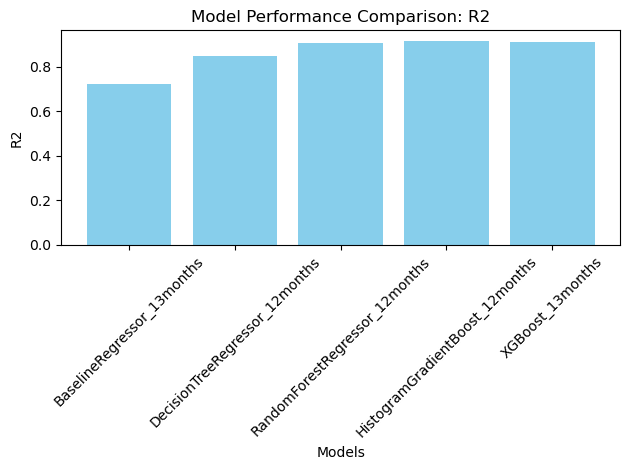

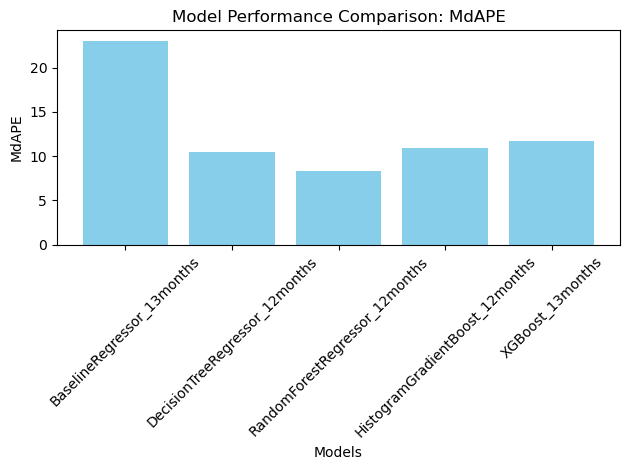

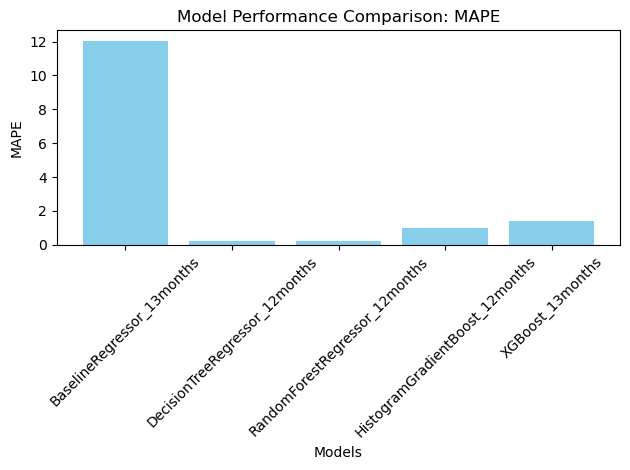

In [62]:
# Efficacy of models. Print out bar charts showing each model's performance for each metric 
# One per test metric

test_metrics = ['R2', 'MdAPE', 'MAPE']

for metric in test_metrics:
    plt.bar(evaluations['Model'], evaluations[metric], color='skyblue')
    plt.title(f'Model Performance Comparison: {metric}')
    plt.xlabel('Models')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

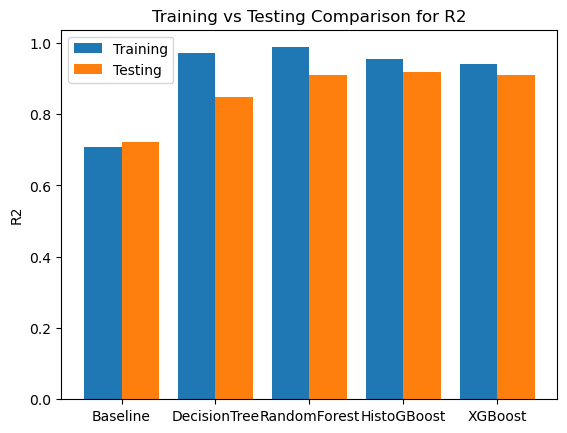

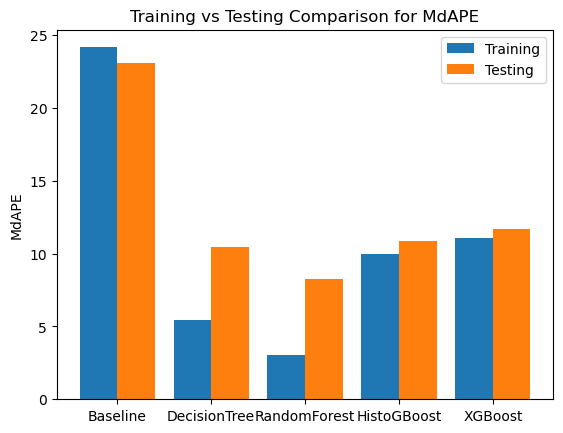

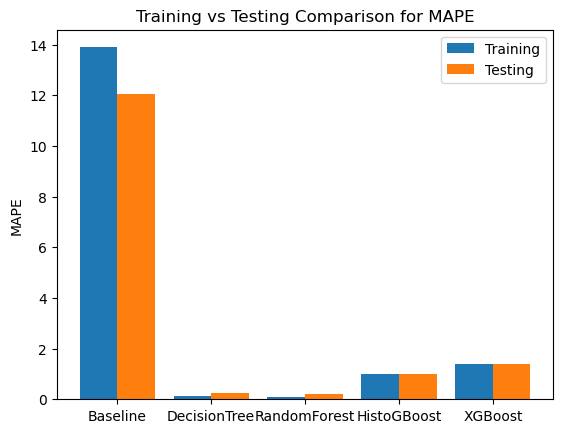

In [63]:
# Graphs comparing their training metrics to test metrics
# https://www.geeksforgeeks.org/python/plotting-multiple-bar-charts-using-matplotlib-in-python/

cats = ['Baseline', 'DecisionTree', 'RandomForest', 'HistoGBoost', 'XGBoost'] # categories
# unblock l8r cats = ['Baseline', 'DecisionTree', 'RandomForestRegressor', 'HistogramGradientBoost', 'XGBoost'] # categories

training_metrics = ['Training_R2', 'Training_MdAPE', 'Training_MAPE']
test_metrics = ['R2', 'MdAPE', 'MAPE']
#print(evaluations[training_metrics])

for metric in test_metrics:
    training_vals, testing_vals = evaluations[f'Training_{metric}'], evaluations[metric]

    # Bar width and x locations
    w, x = 0.4, np.arange(len(cats))

    fig, ax = plt.subplots()
    ax.bar(x - w/2, training_vals, width=w, label='Training')
    ax.bar(x + w/2, testing_vals, width=w, label='Testing')

    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_ylabel(metric)
    ax.set_title(f'Training vs Testing Comparison for {metric}')
    ax.legend()

    plt.show()

# Best model:
- Histogram Gradient Boost: Best time and metrics
- Summarize insights (eg. which price bands performed better)

In [64]:
# histogram model building part 2
def histboost_for_pricebands(training_vars, training_target, price_band):
    params = {
        "max_iter": [100, 300, 500, 600, 1000],
        "max_leaf_nodes": [5, 10, 20, 50, 75, 100],
        "learning_rate": loguniform(0.01, 1),
    }
    
    # Create a GridSearch CV
    model_rand_searchcv = RandomizedSearchCV(HistGradientBoostingRegressor(), params, cv=5, 
                                                scoring={'R2': 'r2', 'MdAPE': 'neg_median_absolute_error', 'MAPE': 'neg_mean_absolute_percentage_error'}, 
                                                refit='R2', n_jobs=-1)
    # fit to data
    model_rand_searchcv.fit(training_vars, training_target)
    
    # create cv
    cv_results = pd.DataFrame(model_rand_searchcv.cv_results_)
    cv_results["R2"] = -cv_results["mean_test_R2"]
    cv_results["MdAPE"] = -cv_results["mean_test_MdAPE"]
    cv_results["MAPE"] = cv_results["mean_test_MAPE"]
    
    print(f"Histogram Gradient Boosted Performance for prices within the {price_band} Percentile:")
    print(cv_results)
    
    # return the best model
    return model_rand_searchcv.best_estimator_

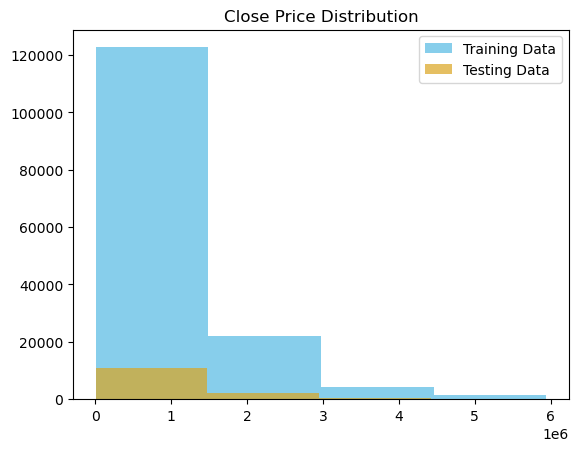

Histogram Gradient Boosted Performance for prices within the 0-25% Percentile:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       5.186149      1.267150         0.537142        0.145197   
1       0.377615      0.026439         0.031650        0.009830   
2       4.089541      0.232981         0.440139        0.060245   
3       1.776250      0.415967         0.149441        0.033916   
4       5.656400      1.585079         0.350638        0.078370   
5       2.732458      0.347908         0.272685        0.057803   
6       3.176733      0.096563         0.242268        0.022011   
7       0.563517      0.068421         0.045184        0.006407   
8       2.366460      0.577231         0.190574        0.031074   
9       1.007266      0.169445         0.078820        0.017246   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.018298            1000                    10   
1             0.859286             300                 

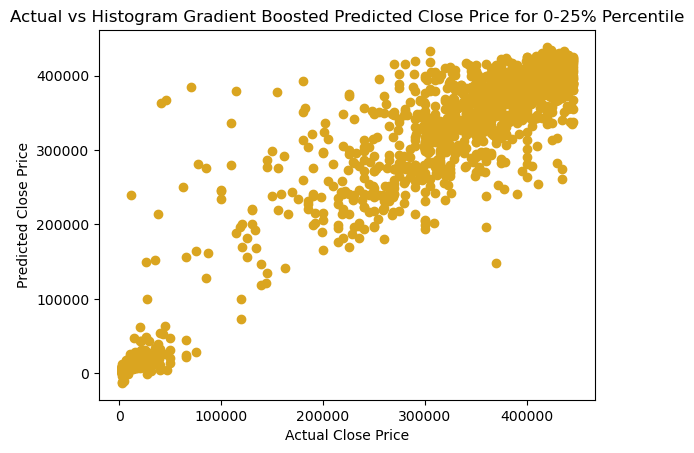

C:\Users\donutii\AppData\Local\Temp\ipykernel_26612\1903940697.py:70: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  performance_per_band = pd.concat([performance_per_band, new_row], ignore_index=True)


Histogram Gradient Boosted Performance for prices within the 26-50% Percentile:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       2.533957      0.234326         0.156010        0.023397   
1       1.218859      0.385939         0.108677        0.048167   
2       2.487874      0.722982         0.139960        0.037878   
3       0.700832      0.155743         0.056528        0.013470   
4       2.991285      0.199196         0.289229        0.041928   
5       2.561796      0.846903         0.135788        0.044660   
6       3.708877      1.044363         0.355161        0.090306   
7       0.854860      0.282543         0.059992        0.019862   
8       4.598683      0.671505         0.217024        0.013890   
9       2.489925      0.686669         0.177388        0.029974   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.012949             100                    50   
1             0.489266             600                

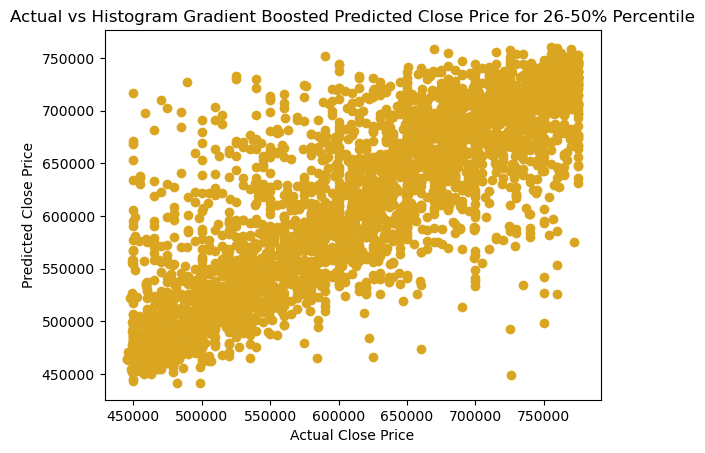

Histogram Gradient Boosted Performance for prices within the 51-90% Percentile:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       1.545783      0.096129         0.133795        0.012049   
1       1.973189      0.297116         0.214847        0.051072   
2       4.962437      0.556120         0.522433        0.030967   
3       3.792654      1.274761         0.306838        0.108783   
4       3.533478      1.102789         0.238433        0.077060   
5       2.069505      0.239702         0.190949        0.015792   
6       1.276793      0.121879         0.119058        0.016561   
7       5.259951      0.093745         0.497586        0.008684   
8       1.241919      0.197222         0.101456        0.014067   
9       1.768583      0.066659         0.135190        0.008213   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.042439             100                    10   
1             0.531500             600                

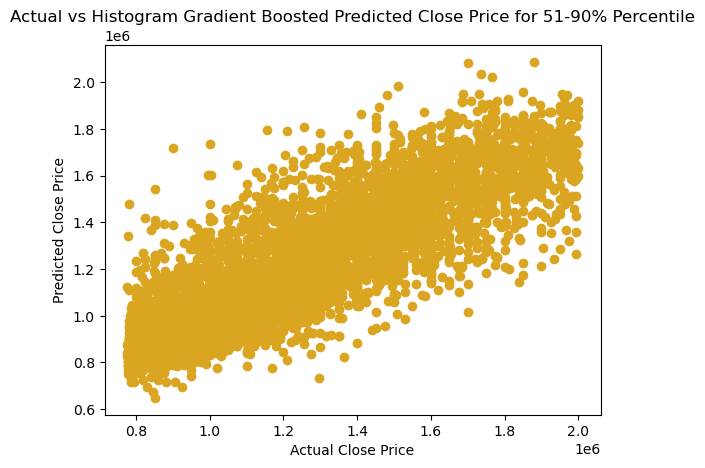

Histogram Gradient Boosted Performance for prices within the 91-100% Percentile:
   mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       0.943678      0.319212         0.080207        0.032896   
1       0.680539      0.349484         0.043246        0.022492   
2      14.234178      0.248284         0.402770        0.048069   
3       3.827177      1.020199         0.241932        0.065597   
4       1.218998      0.613697         0.066672        0.030181   
5       6.367743      0.884164         0.317711        0.067292   
6       0.731191      0.215831         0.043375        0.012315   
7       1.086442      0.056670         0.082349        0.011016   
8       5.960232      1.027848         0.211547        0.051443   
9       0.794999      0.200211         0.035556        0.008174   

   param_learning_rate  param_max_iter  param_max_leaf_nodes  \
0             0.210298             500                     5   
1             0.631939             500               

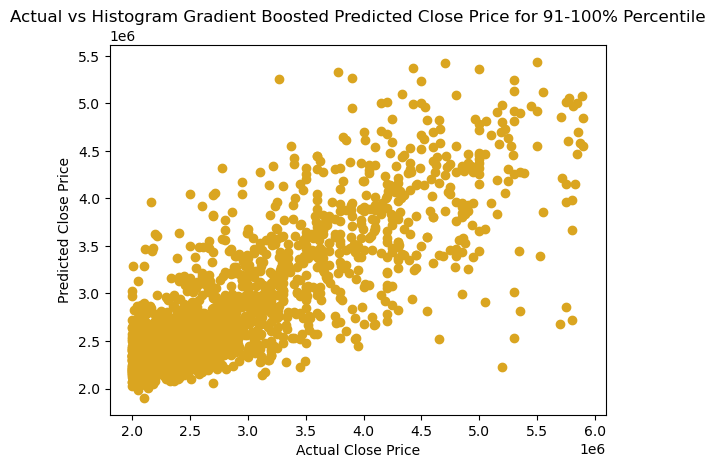

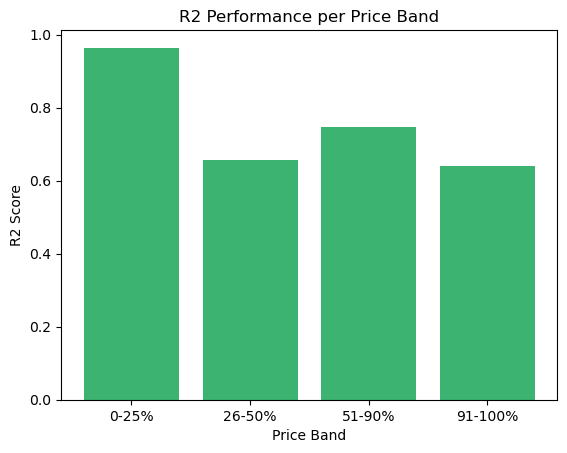

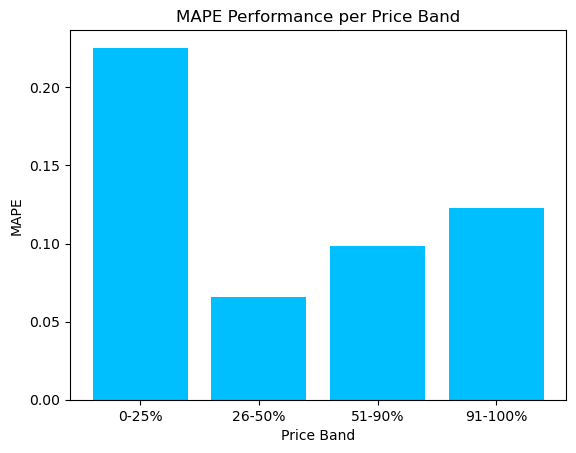

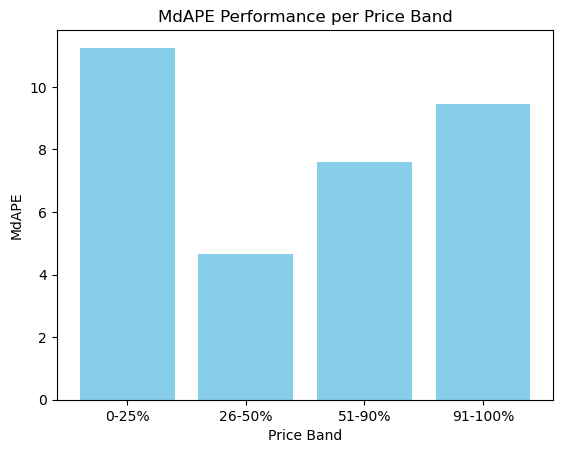

  Price_Band        R2      MdAPE      MAPE
0      0-25%  0.964269  11.250787  0.225333
1     26-50%  0.657866   4.664055  0.065973
2     51-90%  0.747771   7.608133  0.098189
3    91-100%  0.639774   9.463023  0.122521


In [65]:
# divide model into price bands

training_data_bands = choose_test_months(13)
testing_data_bands = testing_set

# Price bands
percentiles = [0, 25, 50, 90, 100]
labels=['0-25%', '26-50%', '51-90%', '91-100%']
cuts = np.percentile(training_data_bands['ClosePrice'], percentiles)

# Use the boundaries to create 4 bands
training_data_bands['price_band'] = pd.cut(
    training_data_bands['ClosePrice'],
    bins=cuts,
    labels=labels,
    include_lowest=True
)
# (Do the same to the testing set as well)
testing_data_bands['price_band'] = pd.cut(
    testing_data_bands['ClosePrice'],
    bins=cuts,
    labels=labels,
    include_lowest=True,
    )

# Display price band dist
plt.hist(training_data_bands['ClosePrice'], bins=len(labels), color='skyblue', label='Training Set')
plt.hist(testing_data_bands['ClosePrice'], bins=len(labels), color='goldenrod', alpha=0.7, label='Testing Set')
plt.title('Close Price Distribution')
plt.legend(['Training Data', 'Testing Data'])
plt.show()

# Split into separate DataFrames by price band
band_dfs = {
    band: df for band, df in training_data_bands.groupby('price_band', observed=True)
}

# Train best model per band
performance_per_band = pd.DataFrame(columns=['Price_Band', 'R2', 'MdAPE', 'MAPE'])

for band, df in band_dfs.items():
    X = df.drop(columns=['ClosePrice', 'price_band'])
    y = df['ClosePrice']
    histboost_model = histboost_for_pricebands(X, y, band)
    test_band_df = testing_data_bands[testing_data_bands['price_band'] == band]
    if test_band_df.shape[0] == 0:
        new_row = pd.DataFrame([{
            'Price_Band': band,
            'R2': np.nan,
            'MdAPE': np.nan,
            'MAPE': np.nan
        }])
    else:
        X_test_band = test_band_df.drop(columns=['ClosePrice', 'price_band'])
        y_test_band = test_band_df['ClosePrice']
        new_row = pd.DataFrame([{
            'Price_Band': band,
            'R2': histboost_model.score(X_test_band, y_test_band),
            'MdAPE': median_absolute_error(y_test_band, histboost_model.predict(X_test_band)),
            'MAPE': mean_absolute_percentage_error(y_test_band, histboost_model.predict(X_test_band))
        }])
        
        plt.scatter(y_test_band, histboost_model.predict(X_test_band), color='goldenrod')
        plt.xlabel('Actual Close Price')
        plt.ylabel('Predicted Close Price')
        plt.title(f'Actual vs Histogram Gradient Boosted Predicted Close Price for {band} Percentile')
        plt.show()
        
        
    performance_per_band = pd.concat([performance_per_band, new_row], ignore_index=True)     

plt.bar(performance_per_band['Price_Band'], performance_per_band['R2'], color='mediumseagreen')
plt.title('R2 Performance per Price Band')
plt.xlabel('Price Band')
plt.ylabel('R2 Score')
plt.show()

plt.bar(performance_per_band['Price_Band'], performance_per_band['MAPE'], color='deepskyblue')
plt.title('MAPE Performance per Price Band')
plt.xlabel('Price Band')
plt.ylabel('MAPE')
plt.show()

plt.bar(performance_per_band['Price_Band'], performance_per_band['MdAPE'], color='skyblue')
plt.title('MdAPE Performance per Price Band')
plt.xlabel('Price Band')
plt.ylabel('MdAPE')
plt.show()

print(performance_per_band)



In [66]:
# Consolidate and export evaluations here

performance_per_band.to_csv('histgrad_perfermance_per_priceband.csv', index = False)